# Word Weight Comparison

This experiment complements `automatic_review_analyzer.ipynb` by comparing the learned word weights produced by the three linear classifiers in Project 1: Perceptron, Average Perceptron, and Pegasos.

Each classifier learns a parameter vector $\theta$ with one component per vocabulary feature. Therefore, word weights are **not specific to Pegasos**; they are a property of the linear bag-of-words model. The learning algorithm determines the values of those weights.

The goal here is to visualize whether the three algorithms identify similar positive and negative words on the same toy dataset. This is an illustrative experiment, not evidence of general NLP performance.

## 1. Imports and data

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'project_1':
    candidate = PROJECT_DIR / 'unit_1' / 'project_1'
    if candidate.exists():
        PROJECT_DIR = candidate
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from review_analyzer import (
    Review, build_vocabulary, vectorize,
    perceptron, average_perceptron, pegasos,
)

reviews = [
    Review(1, 'great excellent good product'),
    Review(1, 'excellent great value'),
    Review(1, 'good product and great quality'),
    Review(-1, 'bad poor product'),
    Review(-1, 'terrible bad quality'),
    Review(-1, 'poor value and terrible experience'),
]

vocabulary = build_vocabulary(reviews)
data = vectorize(reviews, vocabulary)

print(f'Vocabulary size: {len(vocabulary)}')
print(f'Training examples: {len(data)}')

Vocabulary size: 11
Training examples: 6


## 2. Train all three linear classifiers

All three models produce a sparse weight vector indexed by the same vocabulary.

In [2]:
models = {
    'Perceptron': perceptron(data, epochs=20),
    'Average Perceptron': average_perceptron(data, epochs=20),
    'Pegasos': pegasos(data, lambda_=1e-3, epochs=40, seed=3),
}

for name, weights in models.items():
    print(f'{name:20} sparse weights: {len(weights)}')

Perceptron           sparse weights: 5
Average Perceptron   sparse weights: 6
Pegasos              sparse weights: 11


## 3. Compare the learned word weights

A positive weight contributes toward the positive class, while a negative weight contributes toward the negative class. The magnitude indicates how strongly that feature contributes to the linear score.

The classifiers use sparse dictionaries keyed by **vocabulary indices**, not word strings. Therefore, the weights must first be aligned to the vocabulary before plotting them. A sparse model may omit a word whose learned weight is exactly zero.

Plot positions: 11
Perceptron           aligned weights: 11
Average Perceptron   aligned weights: 11
Pegasos              aligned weights: 11


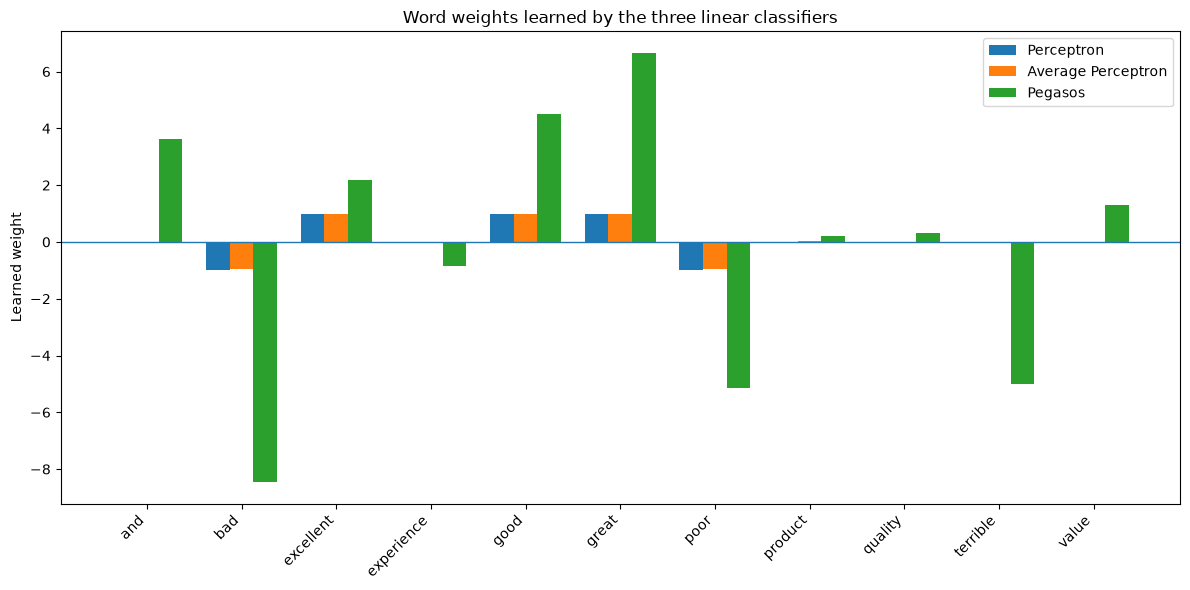

In [3]:
# Build one authoritative x-axis from the vocabulary.
words = sorted(vocabulary, key=vocabulary.get)
indices = np.arange(len(words))

# Expand every sparse model to the exact same dense vocabulary order.
# Missing sparse entries are mathematically zero weights.
aligned_models = {}
for name, weights in models.items():
    values = np.asarray(
        [weights.get(vocabulary[word], 0.0) for word in words],
        dtype=float,
    )
    assert values.shape == indices.shape, (name, values.shape, indices.shape)
    aligned_models[name] = values

print(f'Plot positions: {len(indices)}')
for name, values in aligned_models.items():
    print(f'{name:20} aligned weights: {len(values)}')

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.25

for offset, (name, values) in zip((-width, 0, width), aligned_models.items()):
    ax.bar(indices + offset, values, width=width, label=name)

ax.axhline(0, linewidth=1)
ax.set_xticks(indices)
ax.set_xticklabels(words, rotation=45, ha='right')
ax.set_ylabel('Learned weight')
ax.set_title('Word weights learned by the three linear classifiers')
ax.legend()
plt.tight_layout()
plt.show()

## 4. What to look for

The important observation is that the three algorithms are learning the **same kind of object**: a linear weight for each word feature. Their optimization procedures are different, so the numerical values need not be identical.

Questions to investigate:

1. Do positive words generally receive positive weights?
2. Do negative words generally receive negative weights?
3. Which words have the largest absolute weights?
4. Do Perceptron and Average Perceptron produce similar signs?
5. How does Pegasos' regularization affect the magnitude of the weights?

The experiment should be interpreted qualitatively because the dataset is intentionally tiny.